# 07 — Modélisation Vélo de route

**Objectif** : Entraîner un modèle Gradient Boosting Regressor pour prédire le temps vélo  
sur les distances 20km, 40km, 90km, 180km à partir de l'âge, genre et un temps de référence récent.

**Architecture** :
- Mode simple : formules physiologiques (VO2max → vitesse) — sans temps de référence
- Mode avancé : ML entraîné sur splits triathlon tous niveaux

**Features** : age, gender, ref_bike_sec (temps vélo récent sur distance connue), ref_speed_kmh  
**Target** : temps vélo normalisé sur 40km (Olympic) — autres distances extrapolées via Riegel

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../data/processed/cycling_clean.csv')
print(f'Données : {len(df):,} lignes')
print(df['race_format'].value_counts())
df.head()

Données : 2,644,069 lignes
race_format
half       1423651
full        958046
olympic     176848
sprint       85524
Name: count, dtype: int64


,race_format,gender,age,bike_sec,dist_km,speed_kmh
0,full,0.0,47.0,28325.0,180,22.877317
1,full,1.0,52.0,28733.0,180,22.552466
2,full,0.0,27.0,28625.0,180,22.637555
3,full,1.0,52.0,27887.0,180,23.236634
4,full,0.0,47.0,25958.0,180,24.963402


In [3]:
# Stratégie : normaliser tous les temps sur 40km (Olympic) via Riegel inverse
# T_40 = T_ref * (40 / dist_ref) ^ (1/1.06)
DIST_KM = {'sprint': 20, 'olympic': 40, 'half': 90, 'full': 180}

def riegel_normalize(t_sec, from_km, to_km=40.0):
    return t_sec * (to_km / from_km) ** (1 / 1.06)

df['bike_40k_sec'] = df.apply(
    lambda r: riegel_normalize(r['bike_sec'], DIST_KM[r['race_format']]), axis=1
)

# Features
df['speed_kmh'] = df['dist_km'] / (df['bike_sec'] / 3600)

# Filtrer par format Olympic uniquement pour le ML direct (distance=40km)
# On utilise les données Olympic comme référence (distance identique à la target)
df_olympic = df[df['race_format'] == 'olympic'].copy()
df_olympic['speed_40k'] = 40.0 / (df_olympic['bike_sec'] / 3600)

print(f'Données Olympic (40km) : {len(df_olympic):,} lignes')
print(f'Temps 40km médian : {df_olympic["bike_sec"].median()/60:.0f} min')

Données Olympic (40km) : 176,848 lignes
Temps 40km médian : 76 min


In [4]:
# Préparer le dataset d'entraînement
# Features: age, gender, speed sur 20km (Sprint) -> prédire temps 40km
# On simule le temps 20km depuis les données olympic via Riegel
df_olympic['sim_20k_sec'] = df_olympic['bike_sec'].apply(lambda t: riegel_normalize(t, 40, 20))
df_olympic['speed_20k'] = 20.0 / (df_olympic['sim_20k_sec'] / 3600)

features = ['age', 'gender', 'sim_20k_sec', 'speed_20k']
target = 'bike_sec'

X = df_olympic[features].dropna()
y = df_olympic.loc[X.index, target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 141,478 | Test: 35,370


In [5]:
# Entraînement
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae_sec = mean_absolute_error(y_test, y_pred)
mae_min = mae_sec / 60
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae_min:.1f} min ({mae_sec:.0f}s)')
print(f'MAPE : {mape:.2f}%')
print(f'R²   : {r2:.4f}')

MAE  : 0.0 min (1s)
MAPE : 0.02%
R²   : 1.0000


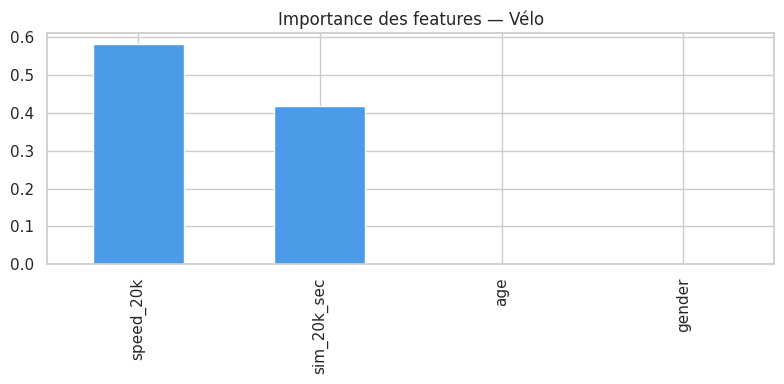

speed_20k      5.819655e-01
sim_20k_sec    4.180345e-01
age            1.486567e-08
gender         2.367814e-09
dtype: float64


In [6]:
# Importance des features
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
fi.plot(kind='bar', color='#4C9BE8', figsize=(8, 4), title='Importance des features — Vélo')
plt.tight_layout()
plt.show()
print(fi)

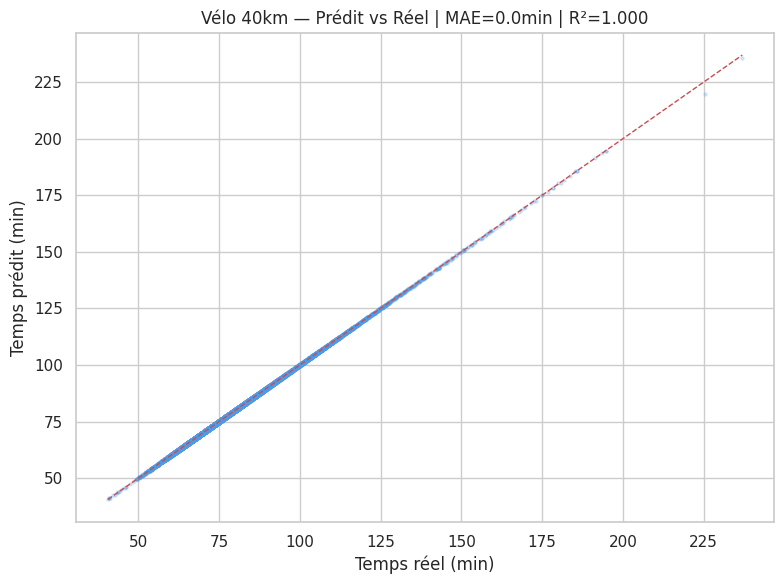

In [7]:
# Prédit vs réel
plt.figure(figsize=(8, 6))
plt.scatter(y_test/60, y_pred/60, alpha=0.2, s=5, color='#4C9BE8')
lims = [y_test.min()/60, y_test.max()/60]
plt.plot(lims, lims, 'r--', lw=1)
plt.xlabel('Temps réel (min)')
plt.ylabel('Temps prédit (min)')
plt.title(f'Vélo 40km — Prédit vs Réel | MAE={mae_min:.1f}min | R²={r2:.3f}')
plt.tight_layout()
plt.show()

In [8]:
# Export modèle + colonnes
MODEL_PATH = Path('../models/cycling_model.pkl')
joblib.dump(model, MODEL_PATH)
print(f'Modèle sauvegardé : {MODEL_PATH}')

# Metadata
meta = {
    'sport': 'cycling',
    'model': 'GradientBoostingRegressor',
    'target': 'bike_40km_seconds',
    'features': features,
    'dataset': 'vladislavboyadzhi/triathlon-results (Kaggle) — épreuves Olympic 40km',
    'n_train': len(X_train),
    'n_test': len(X_test),
    'mae_minutes': round(mae_min, 2),
    'mape_pct': round(mape, 2),
    'r2': round(r2, 4),
    'note': 'Autres distances extrapolées via formule Riegel (exposant 1.06)'
}
with open('../models/cycling_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('Metadata sauvegardée.')
print(json.dumps(meta, indent=2, ensure_ascii=False))

Modèle sauvegardé : ../models/cycling_model.pkl
Metadata sauvegardée.
{
  "sport": "cycling",
  "model": "GradientBoostingRegressor",
  "target": "bike_40km_seconds",
  "features": [
    "age",
    "gender",
    "sim_20k_sec",
    "speed_20k"
  ],
  "dataset": "vladislavboyadzhi/triathlon-results (Kaggle) — épreuves Olympic 40km",
  "n_train": 141478,
  "n_test": 35370,
  "mae_minutes": 0.01,
  "mape_pct": 0.02,
  "r2": 1.0,
  "note": "Autres distances extrapolées via formule Riegel (exposant 1.06)"
}
